# Microproyecto 2 — Alcanzando los Objetivos de Desarrollo Sostenible (ODS)
## Un aporte desde el Machine Learning

**Integrantes:**
- Juan Rojas Ramirez (j.rojasr23@uniandes.edu.co)
- Jared Foster Orduz (j.foster@uniandes.edu.co)

---

### Contexto

La Agenda 2030 de la ONU define 17 Objetivos de Desarrollo Sostenible (ODS). Entidades como el UNFPA requieren
clasificar grandes volúmenes de texto (documentos públicos, resúmenes, reportes, opiniones ciudadanas) según el
ODS con el que se relacionan, tarea que hoy consume muchos recursos humanos especializados.

### Objetivo del proyecto

Desarrollar una solución basada en **NLP + Machine Learning** que:

1. Represente los textos mediante **Bolsa de Palabras (BOW) con ponderación TF-IDF**, integrada en un **pipeline**.
2. Explore un modelo de tópicos con **LSA (TruncatedSVD)** sobre la matriz TF-IDF, interpretando cualitativamente
   los tópicos encontrados frente a los 17 ODS.
3. Construya un **modelo de clasificación multiclase** (16 clases presentes en los datos) que relacione un texto
   con su ODS correspondiente, reduciendo la dimensionalidad del espacio de entrada y realizando **búsqueda de
   hiperparámetros**.
4. **Evalúe** el modelo sobre un conjunto de **test** no utilizado durante el aprendizaje, mostrando evidencia de
   desempeño sobre al menos 4 textos.

### Datos

`Datos_textosODS.xlsx`: subconjunto en español (traducido con DeepL y aumentado con la API de ChatGPT) del
**OSDG Community Dataset (OSDG-CD) 2023**, con dos columnas:

* `textos`: texto libre relacionado con un ODS.
* `ODS`: etiqueta numérica (1-17) del Objetivo de Desarrollo Sostenible asociado.

### Estructura del notebook

1. Carga de librerías y datos
2. Exploración de datos (EDA)
3. División train / test
4. Preprocesamiento de texto y pipeline BOW-TF-IDF
5. Modelado de tópicos con LSA (TruncatedSVD) e interpretación cualitativa
6. Modelo de clasificación: reducción de dimensionalidad + búsqueda de hiperparámetros
7. Evaluación sobre el conjunto de test
8. Evidencia de desempeño sobre textos individuales
9. Conclusiones
10. (Bonus opcional) Artefactos para despliegue con Streamlit


## 1. Carga de librerías y datos

In [1]:
# Librerías generales
import re
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
from nltk.stem.snowball import SnowballStemmer

# scikit-learn
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('Librerías cargadas correctamente.')


Librerías cargadas correctamente.


In [2]:
# Carga del conjunto de datos
df = pd.read_excel('Datos_textosODS.xlsx')
print('Dimensiones del dataset:', df.shape)
df.head()


Dimensiones del dataset: (9656, 2)


,textos,ODS
0,"""Aprendizaje"" y ""educación"" se consideran sinó...",4
1,No dejar clara la naturaleza de estos riesgos ...,6
2,"Como resultado, un mayor y mejorado acceso al ...",13
3,Con el Congreso firmemente en control de la ju...,16
4,"Luego, dos secciones finales analizan las impl...",5


In [3]:
# Revisión general: tipos de datos, nulos y duplicados
print(df.dtypes)
print('\nValores nulos por columna:')
print(df.isna().sum())
print('\nTextos duplicados exactos:', df.duplicated(subset=['textos']).sum())
print('\nValores únicos de ODS presentes:', sorted(df['ODS'].unique()))


textos    object
ODS        int64
dtype: object

Valores nulos por columna:
textos    0
ODS       0
dtype: int64

Textos duplicados exactos: 0

Valores únicos de ODS presentes: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16)]


El conjunto de datos **no tiene valores nulos ni textos duplicados exactos**, por lo que no se requieren
pasos de limpieza estructural adicionales. Se observa que están presentes **16 de los 17 ODS** (falta el ODS 17,
*Alianzas para lograr los objetivos*), por lo que el problema de clasificación se trabajará sobre **16 clases**.

## 2. Exploración de datos (EDA)

Antes de construir cualquier pipeline es importante entender la distribución de clases (para decidir métricas de
evaluación y estrategias de partición/ponderación) y las características básicas del texto.

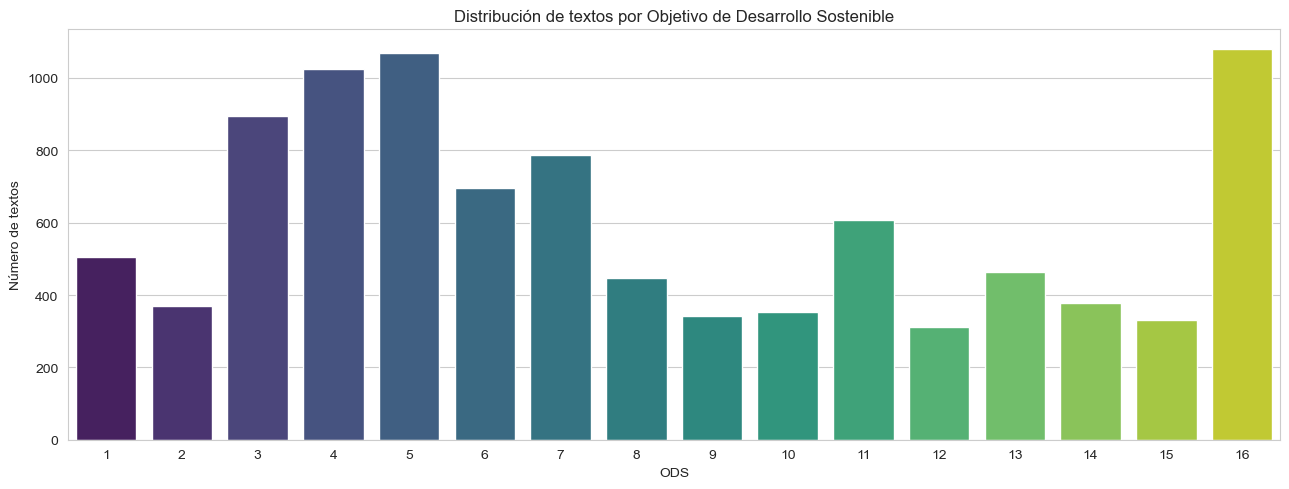

Clase más frecuente: ODS 16 (1080 textos)
Clase menos frecuente: ODS 12 (312 textos)
Razón desbalance (max/min): 3.46


In [4]:
# Nombres oficiales de los ODS, para hacer más legibles los gráficos e interpretaciones
ODS_NAMES = {
    1: 'Fin de la pobreza', 2: 'Hambre cero', 3: 'Salud y bienestar',
    4: 'Educación de calidad', 5: 'Igualdad de género', 6: 'Agua limpia y saneamiento',
    7: 'Energía asequible y no contaminante', 8: 'Trabajo decente y crecimiento económico',
    9: 'Industria, innovación e infraestructura', 10: 'Reducción de las desigualdades',
    11: 'Ciudades y comunidades sostenibles', 12: 'Producción y consumo responsables',
    13: 'Acción por el clima', 14: 'Vida submarina', 15: 'Vida de ecosistemas terrestres',
    16: 'Paz, justicia e instituciones sólidas', 17: 'Alianzas para lograr los objetivos'
}

conteo = df['ODS'].value_counts().sort_index()
etiquetas = [f"ODS {i}\n{ODS_NAMES[i]}" for i in conteo.index]

fig, ax = plt.subplots(figsize=(13, 5))
sns.barplot(x=conteo.index.astype(str), y=conteo.values, palette='viridis', ax=ax)
ax.set_xlabel('ODS')
ax.set_ylabel('Número de textos')
ax.set_title('Distribución de textos por Objetivo de Desarrollo Sostenible')
plt.tight_layout()
plt.show()

print('Clase más frecuente: ODS', conteo.idxmax(), f'({conteo.max()} textos)')
print('Clase menos frecuente: ODS', conteo.idxmin(), f'({conteo.min()} textos)')
print('Razón desbalance (max/min):', round(conteo.max()/conteo.min(), 2))


**Observación:** existe un desbalance moderado entre clases (relación aproximada de 3.5:1 entre la clase más
y menos frecuente). Esto es relevante para dos decisiones que se tomarán más adelante:

* Usar **partición estratificada** (train/test y validación cruzada) para conservar las proporciones de clase.
* Usar **F1-macro** (y no solo *accuracy*) como métrica principal de evaluación, ya que pondera igual a todas las
  clases sin que las mayoritarias dominen la métrica, y considerar `class_weight='balanced'` en los clasificadores.

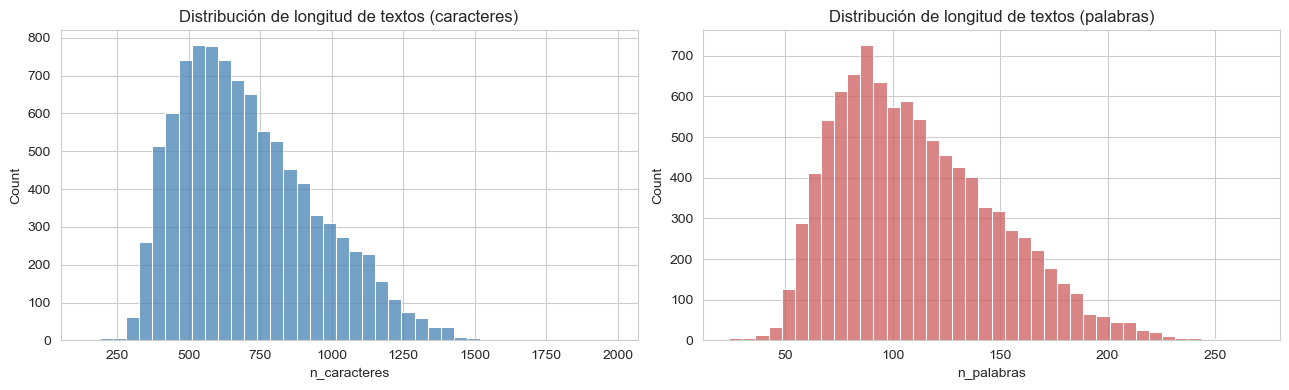

,n_caracteres,n_palabras
count,9656.000000,9656.000000
mean,708.952465,111.017295
std,238.864636,37.082212
min,143.000000,24.000000
25%,522.000000,82.000000
50%,669.000000,105.000000
75%,864.000000,135.000000
max,1977.000000,268.000000


In [5]:
# Longitud de los textos (en caracteres y en palabras)
df['n_caracteres'] = df['textos'].str.len()
df['n_palabras'] = df['textos'].str.split().apply(len)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df['n_caracteres'], bins=40, ax=axes[0], color='steelblue')
axes[0].set_title('Distribución de longitud de textos (caracteres)')
sns.histplot(df['n_palabras'], bins=40, ax=axes[1], color='indianred')
axes[1].set_title('Distribución de longitud de textos (palabras)')
plt.tight_layout()
plt.show()

df[['n_caracteres', 'n_palabras']].describe()


In [6]:
# Ejemplo de textos por ODS (muestra aleatoria)
pd.set_option('display.max_colwidth', 120)
df.sample(5, random_state=RANDOM_STATE)[['textos', 'ODS']]


,textos,ODS
8522,"Por supuesto, el incentivo para sobrepescar y vender el pescado fuera del conjunto de puertos controlados (en el cas...",14
9557,"Los maestros de preescolar y jardín de infancia deben ser licenciados. Cada primavera, miles de bachilleres presenta...",4
1527,"Por lo general, se trata de iniciativas generales que abordan las necesidades de capital para una amplia gama de pro...",9
7707,"En Tanzania, las instituciones académicas y de investigación participaron activamente en la redacción de la Ley de R...",14
3502,"En sociedades divididas, la policía tiende a estar estrechamente alineada con el grupo social dominante y sus accion...",16


## 3. División train / test

La partición en entrenamiento y prueba se realiza **antes** de ajustar cualquier transformación (TF-IDF, SVD,
etc.) para evitar *data leakage*: todos los transformadores se ajustarán únicamente sobre el conjunto de
entrenamiento y luego se aplicarán (transform) al conjunto de prueba. La partición es **estratificada** por `ODS`
para conservar la proporción de clases en ambos conjuntos, dado el desbalance observado en el EDA.

Se reserva un 20% de los datos para prueba, un tamaño suficiente (~1930 textos) para obtener una estimación
estable del desempeño y a la vez dejar suficientes ejemplos por clase para el entrenamiento.

In [7]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df['textos'], df['ODS'],
    test_size=0.2,
    stratify=df['ODS'],
    random_state=RANDOM_STATE
)

print('Train:', X_train_raw.shape[0], 'textos')
print('Test :', X_test_raw.shape[0], 'textos')

# Verificación de que las proporciones de clase se conservan en ambos conjuntos
comp = pd.DataFrame({
    'train_%': (y_train.value_counts(normalize=True).sort_index() * 100).round(2),
    'test_%': (y_test.value_counts(normalize=True).sort_index() * 100).round(2)
})
comp


Train: 7724 textos
Test : 1932 textos


,train_%,test_%
ODS,,
1,5.23,5.23
2,3.82,3.83
3,9.26,9.27
4,10.62,10.61
5,11.08,11.08
6,7.20,7.19
7,8.14,8.18
8,4.62,4.61
9,3.55,3.57


## 4. Preprocesamiento de texto y pipeline BOW-TF-IDF

### Decisiones de limpieza y justificación

| Transformación | Justificación |
|---|---|
| Minúsculas | Evita tratar "Educación" y "educación" como términos distintos. |
| Eliminación de URLs | Los textos provienen de reportes/documentos y pueden contener enlaces sin valor semántico. |
| Eliminación de dígitos y puntuación | Se conserva solo información léxica; los números aislados aportan poco a la temática ODS y añaden dispersión al vocabulario. |
| Eliminación de *stopwords* en español (NLTK) | Palabras funcionales (preposiciones, artículos, etc.) no aportan a diferenciar los ODS y aumentan innecesariamente la dimensionalidad. |
| *Stemming* (SnowballStemmer español) | El español es un idioma con alta flexión morfológica (género, número, conjugaciones). El *stemming* agrupa variantes de una misma raíz (p. ej. "educar", "educación", "educativo" → "educ"), reduciendo la dispersión del vocabulario y reforzando la señal estadística de TF-IDF. |
| Filtrado de tokens muy cortos (≤ 2 caracteres) | Elimina ruido (partículas sueltas, restos de tokenización). |
| TF-IDF con `sublinear_tf=True` | Atenúa el efecto de palabras muy repetidas dentro de un mismo documento (escala logarítmica), habitual en textos largos. |
| `ngram_range=(1,2)` | Además de palabras individuales, se capturan bigramas relevantes para el dominio (p. ej. *"cambio climático"*, *"derechos humanos"*, *"energía renovable"*), que son más informativos que sus componentes por separado. |
| `min_df=5`, `max_df=0.85` | Se descartan términos extremadamente raros (posible ruido/errores) y términos casi universales (poco discriminantes entre ODS). |

Todas estas transformaciones se integran en un **pipeline de scikit-learn** (`TextCleaner` + `TfidfVectorizer`) que
se ajusta **únicamente sobre el conjunto de entrenamiento**, evitando así fuga de información del conjunto de
prueba hacia el vocabulario/estadísticas TF-IDF.

In [8]:
spanish_stopwords = set(stopwords.words('spanish'))
stemmer = SnowballStemmer('spanish')

def limpiar_texto(texto):
    # Normaliza un texto: minúsculas, sin URLs/dígitos/puntuación, sin stopwords, con stemming.
    texto = str(texto).lower()
    texto = re.sub(r'http\S+|www\.\S+', ' ', texto)          # URLs
    texto = re.sub(r'[^a-záéíóúñü\s]', ' ', texto)             # solo letras (incluye tildes/ñ)
    tokens = texto.split()
    tokens = [stemmer.stem(t) for t in tokens if t not in spanish_stopwords and len(t) > 2]
    return ' '.join(tokens)


class TextCleaner(BaseEstimator, TransformerMixin):
    # Transformador de scikit-learn que aplica `limpiar_texto` a una serie/lista de textos,
    # permitiendo integrar la limpieza dentro de un Pipeline de sklearn.

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return [limpiar_texto(t) for t in X]


# Ejemplo de limpieza sobre un texto real del conjunto de entrenamiento
ejemplo_original = X_train_raw.iloc[0]
ejemplo_limpio = limpiar_texto(ejemplo_original)
print('ORIGINAL:\n', ejemplo_original[:300], '...\n')
print('LIMPIO:\n', ejemplo_limpio[:300], '...')


ORIGINAL:
 Por lo tanto, cabe esperar que el aumento de los niveles de ingresos posterior a la reforma de la asistencia social, tanto para los que tienen trabajo como para los que no tienen, tenga un efecto positivo en los niños. Una revisión de la evidencia sobre la reforma del bienestar y los resultados de l ...

LIMPIO:
 cab esper aument nivel ingres posterior reform asistent social trabaj efect posit niñ revision evident reform bienest result niñ unid waldfogel conclu vulner ten desempeñ deficient result cambi polit joven menor dos años adolescent probabl ocurr efect perjudicial gananci ingres madr trabaj emple sal ...


In [9]:
# Pipeline de preparación de texto: limpieza -> TF-IDF
tfidf_pipeline = Pipeline([
    ('cleaner', TextCleaner()),
    ('tfidf', TfidfVectorizer(
        min_df=5,
        max_df=0.85,
        ngram_range=(1, 2),
        max_features=20000,
        sublinear_tf=True
    ))
])

t0 = time.time()
X_train_tfidf = tfidf_pipeline.fit_transform(X_train_raw)
X_test_tfidf = tfidf_pipeline.transform(X_test_raw)
print(f'Tiempo de ajuste+transformación: {time.time()-t0:.2f} s')

print('Matriz TF-IDF (train):', X_train_tfidf.shape)
print('Matriz TF-IDF (test) :', X_test_tfidf.shape)
print('Tamaño de vocabulario:', len(tfidf_pipeline.named_steps["tfidf"].vocabulary_))


Tiempo de ajuste+transformación: 23.35 s
Matriz TF-IDF (train): (7724, 13665)
Matriz TF-IDF (test) : (1932, 13665)
Tamaño de vocabulario: 13665


In [10]:
# Sanity-check: términos con mayor peso TF-IDF promedio en el corpus de entrenamiento
terms = np.array(tfidf_pipeline.named_steps['tfidf'].get_feature_names_out())
mean_tfidf = np.asarray(X_train_tfidf.mean(axis=0)).ravel()
top_idx = mean_tfidf.argsort()[::-1][:25]

top_terms_df = pd.DataFrame({'término (raíz)': terms[top_idx], 'peso TF-IDF promedio': mean_tfidf[top_idx].round(4)})
top_terms_df


,término (raíz),peso TF-IDF promedio
0,pais,0.0179
1,pued,0.0177
2,desarroll,0.0163
3,polit,0.0157
4,mayor,0.0139
5,deb,0.0136
6,aument,0.0130
7,mejor,0.0130
8,trabaj,0.0130
9,mujer,0.0127


Los términos con mayor peso promedio (*pobrez*, *educ*, *mujer*, *salud*, *climat*, *energ*, *agu*, *derech*...)
son consistentes con el vocabulario esperado para textos relacionados con los ODS, lo que da un primer indicio
de que la representación TF-IDF está capturando información relevante del dominio.

## 5. Modelado de tópicos con LSA (TruncatedSVD)

Se aplica **Análisis Semántico Latente (LSA)** mediante `TruncatedSVD` sobre la matriz TF-IDF del conjunto de
entrenamiento, con el fin de descubrir combinaciones lineales de términos ("tópicos") que resuman la variabilidad
semántica del corpus y explorar cualitativamente si estos tópicos se relacionan con los ODS.

### Selección del número de componentes

El enunciado sugiere explorar entre 10 y 20 componentes. Se compara la varianza explicada acumulada para varios
valores candidatos.

n_components= 10 -> varianza explicada acumulada = 3.19 %
n_components= 15 -> varianza explicada acumulada = 4.21 %
n_components= 20 -> varianza explicada acumulada = 5.04 %
n_components= 30 -> varianza explicada acumulada = 6.47 %
n_components= 50 -> varianza explicada acumulada = 8.92 %
n_components=100 -> varianza explicada acumulada = 13.87 %


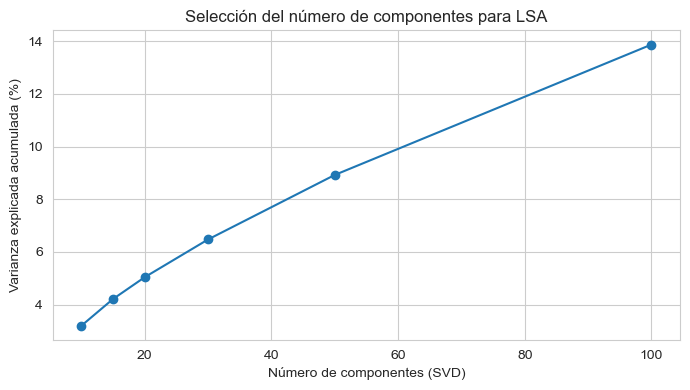

In [11]:
candidatos = [10, 15, 20, 30, 50, 100]
varianzas = []
for n in candidatos:
    svd_tmp = TruncatedSVD(n_components=n, random_state=RANDOM_STATE)
    svd_tmp.fit(X_train_tfidf)
    varianzas.append(svd_tmp.explained_variance_ratio_.sum())
    print(f'n_components={n:>3} -> varianza explicada acumulada = {varianzas[-1]*100:.2f} %')

plt.figure(figsize=(7,4))
plt.plot(candidatos, np.array(varianzas)*100, marker='o')
plt.xlabel('Número de componentes (SVD)')
plt.ylabel('Varianza explicada acumulada (%)')
plt.title('Selección del número de componentes para LSA')
plt.tight_layout()
plt.show()


Como es típico en espacios TF-IDF de alta dimensionalidad y vocabulario amplio (~20.000 términos), la varianza
explicada acumulada por un número reducido de componentes es baja en términos absolutos (esto **no** invalida el
análisis: en LSA lo relevante no es "explicar toda la varianza" sino capturar las direcciones semánticas
dominantes que permiten interpretar tópicos y, más adelante, sirvan como espacio reducido para clasificación).

Se selecciona **`n_components = 15`** para el análisis de tópicos (dentro del rango 10-20 sugerido): es un número
suficientemente pequeño para que cada componente sea interpretable manualmente, y suficientemente grande para
capturar más de un eje temático relevante frente a los 16 ODS presentes en los datos.

In [12]:
N_TOPICS = 15
lsa_model = TruncatedSVD(n_components=N_TOPICS, random_state=RANDOM_STATE)
X_train_lsa = lsa_model.fit_transform(X_train_tfidf)

print('Varianza explicada por cada componente (%):')
print(np.round(lsa_model.explained_variance_ratio_ * 100, 2))
print('\nVarianza explicada acumulada por las 15 componentes: {:.2f} %'.format(
    lsa_model.explained_variance_ratio_.sum() * 100))


Varianza explicada por cada componente (%):
[0.09 0.51 0.48 0.39 0.33 0.31 0.31 0.29 0.24 0.23 0.23 0.21 0.2  0.19
 0.18]

Varianza explicada acumulada por las 15 componentes: 4.21 %


--- Tópico (componente) 1 — varianza explicada: 0.09 % ---
  Términos con carga POSITIVA : pued, pais, desarroll, polit, mayor, deb, mejor, trabaj, mujer, aument
  Términos con carga NEGATIVA : produccion algas, anuari fao, acuicultur ajust, estadist pesc, fao estadist, numer especi, valor chin, rom cort, pdf, internacional genocidi

--- Tópico (componente) 2 — varianza explicada: 0.51 % ---
  Términos con carga POSITIVA : derech, derech human, human, internacional, articul, derech internacional, ley, tribunal, polit, legal
  Términos con carga NEGATIVA : energ, aument, ingres, agu, cost, pais, mayor, tas, pobrez, electr

--- Tópico (componente) 3 — varianza explicada: 0.48 % ---
  Términos con carga POSITIVA : mujer, trabaj, educ, hombr, niñ, laboral, ingres, emple, pobrez, tas
  Términos con carga NEGATIVA : agu, energ, energet, climat, gestion, desarroll, renov, electr, eficient, uso

--- Tópico (componente) 4 — varianza explicada: 0.39 % ---
  Términos con carga POSITIVA : educ, es

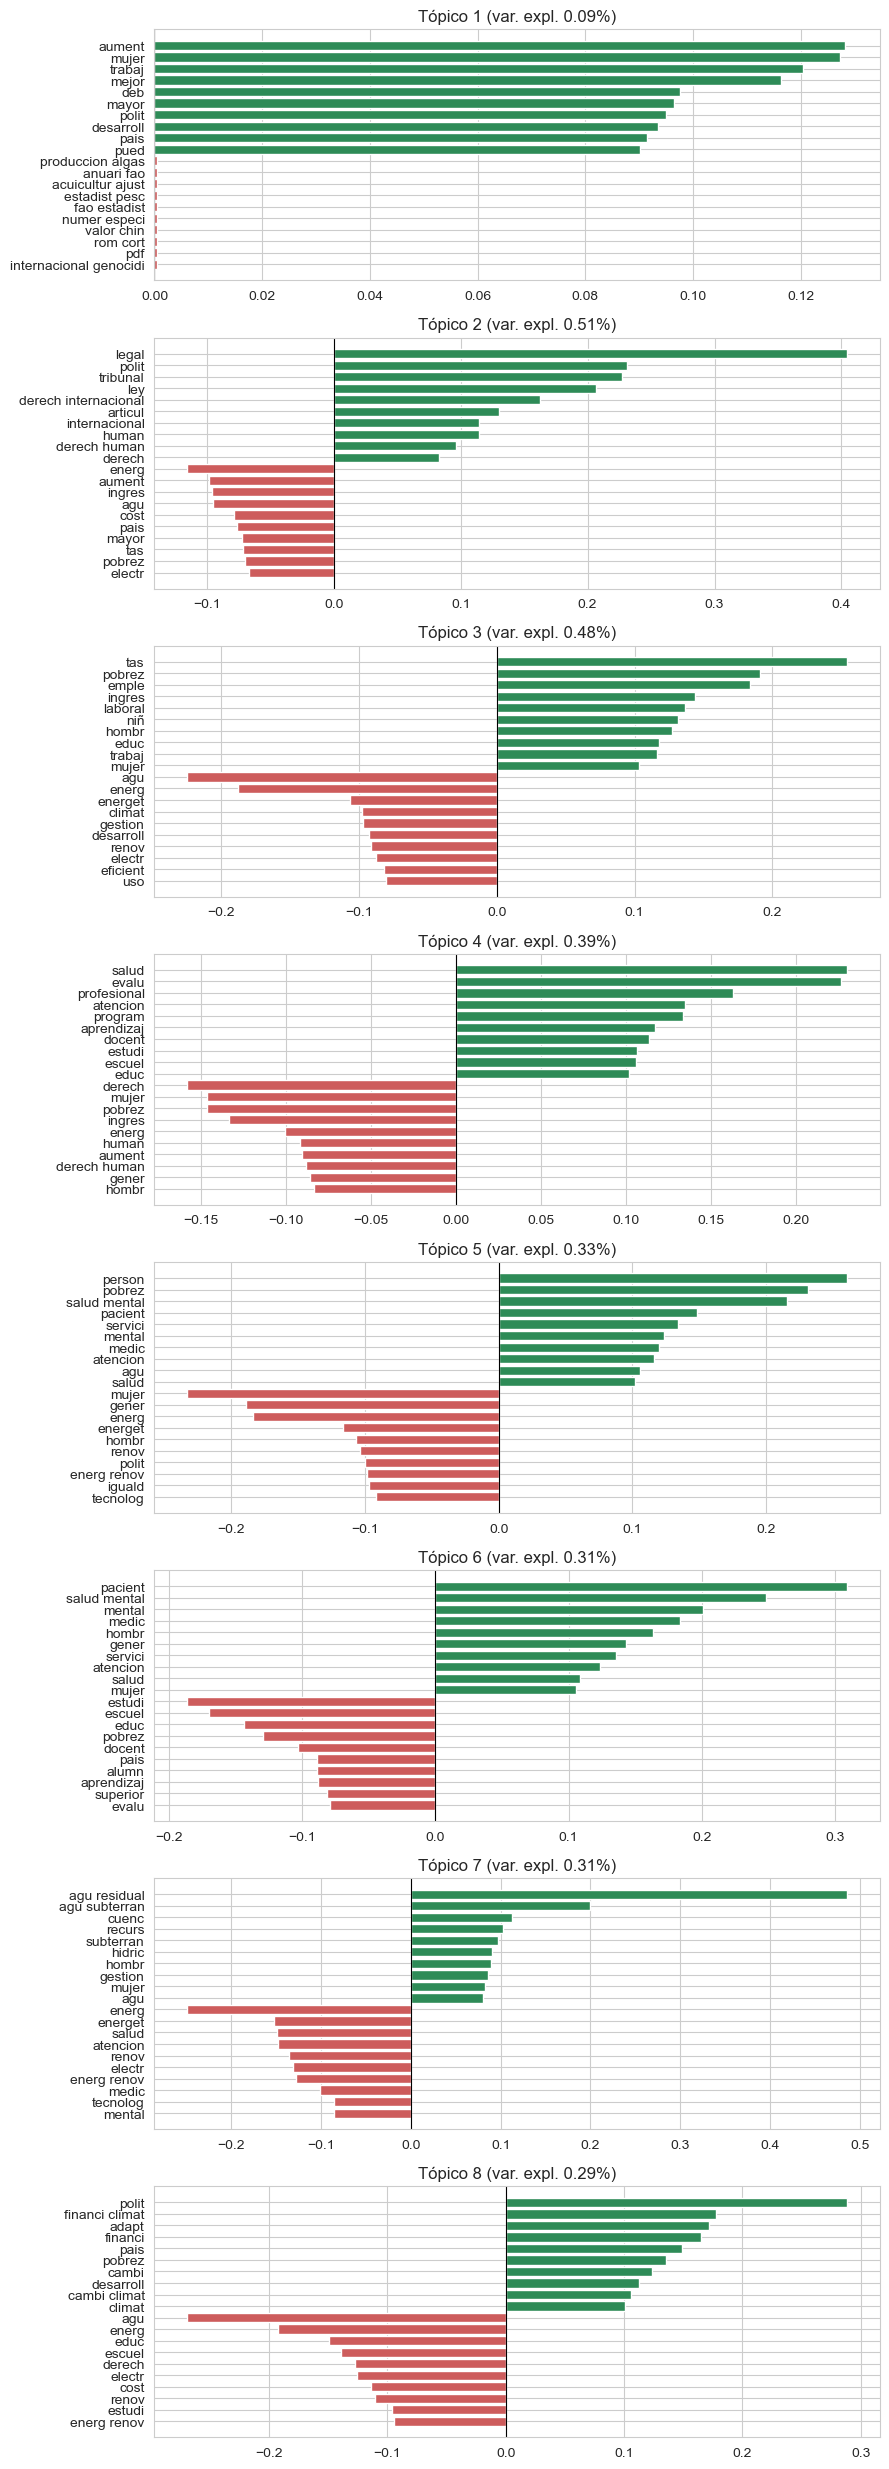

In [13]:
def top_terminos_componente(componente, terminos, n=12):
    # Devuelve los `n` términos con mayor peso positivo y negativo de una componente de LSA.
    orden = np.argsort(componente)
    top_neg = terminos[orden[:n]]
    top_pos = terminos[orden[-n:]][::-1]
    return top_pos, top_neg


N_TOPICOS_A_MOSTRAR = 8
fig, axes = plt.subplots(N_TOPICOS_A_MOSTRAR, 1, figsize=(9, 3.1 * N_TOPICOS_A_MOSTRAR))

for i in range(N_TOPICOS_A_MOSTRAR):
    comp = lsa_model.components_[i]
    top_pos, top_neg = top_terminos_componente(comp, terms, n=10)
    print(f'--- Tópico (componente) {i+1} — varianza explicada: {lsa_model.explained_variance_ratio_[i]*100:.2f} % ---')
    print('  Términos con carga POSITIVA :', ', '.join(top_pos))
    print('  Términos con carga NEGATIVA :', ', '.join(top_neg))
    print()

    ax = axes[i]
    palabras = list(top_neg[::-1]) + list(top_pos)
    valores = list(comp[np.argsort(comp)][:10][::-1]) + list(comp[np.argsort(comp)][-10:])
    colores = ['indianred'] * 10 + ['seagreen'] * 10
    ax.barh(palabras, valores, color=colores)
    ax.set_title(f'Tópico {i+1} (var. expl. {lsa_model.explained_variance_ratio_[i]*100:.2f}%)')
    ax.axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()


### Interpretación cualitativa de los tópicos frente a los ODS

> Nota: los términos aparecen con su raíz (*stem*), p. ej. `educ` agrupa "educación/educativo/educar", `energ`
> agrupa "energía/energético", `agu` agrupa "agua".

* **Tópico 1** (carga negativa dominada por *producción algas, anuario fao, estadísticas pesca, acuicultura*):
  aísla un subconjunto de documentos muy específicos de estadísticas pesqueras/acuícolas, claramente relacionados
  con **ODS 14 — Vida submarina**. El lado positivo agrupa vocabulario genérico de política y desarrollo (*país,
  desarrollo, política, mejorar*), típico del "tópico general" que suele emerger en la primera componente de LSA.

* **Tópico 2** (positivo: *derecho, derecho humano, internacional, tribunal, ley, justicia, tratado* — negativo:
  *energía, ingreso, agua, costo, pobreza, electricidad*): contrapone un eje claramente asociado a **ODS 16 — Paz,
  justicia e instituciones sólidas** frente a un eje de acceso a servicios básicos y pobreza (**ODS 1 / ODS 7 /
  ODS 6**).

* **Tópico 3** (positivo: *mujer, trabajo, educación, hombre, niño, laboral, ingreso, empleo, escuela* — negativo:
  *agua, energía, climático, renovable, eficiencia*): separa temas de **género, educación y trabajo (ODS 5, ODS 4,
  ODS 8)** de temas de **energía y clima (ODS 7, ODS 13)**.

* **Tópico 4** (positivo: *educación, escuela, estudiante, docente, aprendizaje, enseñanza* — negativo: *derecho,
  mujer, pobreza, ingreso, desigualdad*): un eje muy nítido de **ODS 4 — Educación de calidad** frente a un eje de
  **desigualdad/pobreza/género (ODS 10, ODS 1, ODS 5)**.

* **Tópico 5** (positivo: *salud, agua, atención, médico, salud mental, paciente, atención primaria* — negativo:
  *mujer, género, energía, renovable, igualdad*): eje de **ODS 3 — Salud y bienestar** frente a **ODS 5 / ODS 7**.

* **Tópico 6** (positivo: *mujer, salud, atención, género, médico, salud mental* — negativo: *estudio, escuela,
  educación, docente, aprendizaje*): combina **salud y género (ODS 3, ODS 5)** frente a **educación (ODS 4)**.

* **Tópico 7** (positivo: *agua, gestión, hídrico, subterránea, cuenca, agua residual, recursos hídricos* —
  negativo: *energía, salud, renovable, electricidad*): eje muy limpio de **ODS 6 — Agua limpia y saneamiento**
  frente a **energía y salud (ODS 7, ODS 3)**.

* **Tópico 8** (positivo: *climático, cambio climático, financiamiento, adaptación, financiamiento climático,
  países desarrollados* — negativo: *agua, energía, educación, escuela, derecho*): eje muy claro de **ODS 13 —
  Acción por el clima**.

**Conclusión de la interpretación:** aunque LSA es un método **no supervisado** (no utiliza las etiquetas `ODS`
en ningún momento), varios de los tópicos encontrados son **directamente interpretables como ejes temáticos que
coinciden con ODS específicos** (educación → ODS4, agua → ODS6, clima → ODS13, salud → ODS3, derechos/justicia →
ODS16, pesca/acuicultura → ODS14, género/trabajo → ODS5/ODS8). Esto confirma que la representación TF-IDF +
vocabulario en español conserva señal semántica suficiente para diferenciar los ODS, y motiva su uso como espacio
de entrada reducido para el modelo de clasificación supervisado de la siguiente sección.

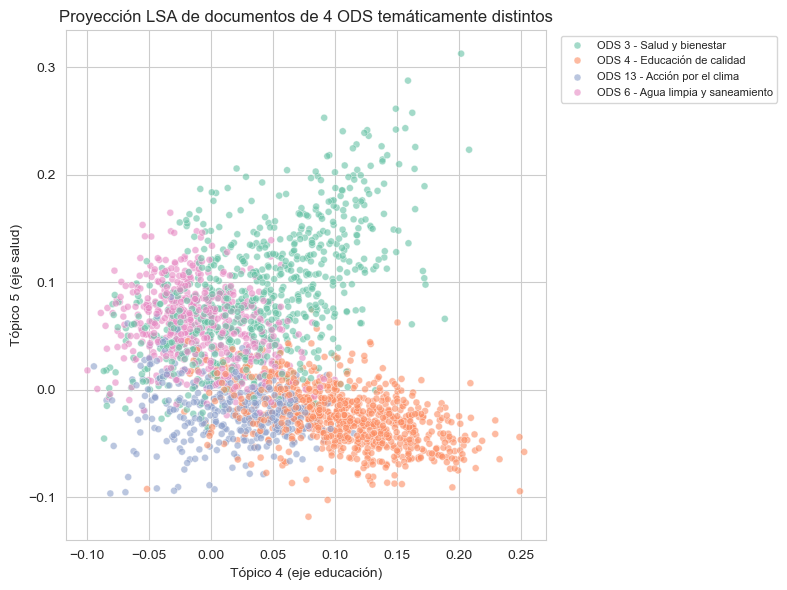

In [14]:
# Visualización 2D de un subconjunto de ODS sobre dos tópicos temáticamente muy claros:
# Tópico 4 (educación) vs Tópico 5 (salud)
ods_ejemplo = [3, 4, 6, 13]  # Salud, Educación, Agua, Clima: los 4 ejes más "limpios" encontrados arriba
mask = y_train.isin(ods_ejemplo)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=X_train_lsa[mask.values, 3],   # Tópico 4 -> educación
    y=X_train_lsa[mask.values, 4],   # Tópico 5 -> salud
    hue=y_train[mask].map(lambda x: f'ODS {x} - {ODS_NAMES[x]}'),
    palette='Set2', alpha=0.6, s=25
)
plt.xlabel('Tópico 4 (eje educación)')
plt.ylabel('Tópico 5 (eje salud)')
plt.title('Proyección LSA de documentos de 4 ODS temáticamente distintos')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()


Se observa una **agrupación visible** de los documentos de ODS 4 (Educación) y ODS 3 (Salud) hacia extremos
opuestos de estos dos tópicos, mientras que ODS 6 (Agua) y ODS 13 (Clima) se ubican en zonas intermedias/menos
diferenciadas en este plano particular — lo esperable, dado que cada par de tópicos solo captura 2 de los 15 ejes
disponibles. Esto refuerza la idea de que el espacio reducido por LSA contiene información útil para la tarea de
clasificación, aunque se requieren más componentes (no solo 2) para separar adecuadamente las 16 clases.

## 6. Modelo de clasificación

### Reducción de dimensionalidad

Se reutiliza el mismo enfoque de reducción de dimensionalidad de la actividad anterior (**TruncatedSVD / LSA**)
como paso del pipeline de clasificación, pero **sin limitar el número de componentes a 15** como en el análisis
de tópicos (donde priorizaba la interpretabilidad): para clasificación se busca **maximizar la información
discriminante** conservada, por lo que el número óptimo de componentes se determina mediante **búsqueda de
hiperparámetros** (ver más abajo), en un rango más amplio (100-300 componentes). Esto es consistente con la
recomendación del enunciado de reutilizar la misma técnica de descomposición.

Ventajas de usar SVD como reducción de dimensionalidad antes de clasificar:

* La matriz TF-IDF es muy dispersa y de alta dimensión (~20.000 columnas); reducirla acelera el entrenamiento y
  disminuye el riesgo de sobreajuste.
* SVD captura las direcciones de mayor varianza semántica, actuando como un "denoising" del espacio de entrada.

### Selección y justificación del algoritmo de clasificación

Se comparan dos algoritmos lineales ampliamente utilizados y eficientes para clasificación de texto de alta
dimensión:

* **Regresión Logística multinomial**: modelo probabilístico, permite obtener `predict_proba`, es interpretable
  y rápido de entrenar.
* **Support Vector Classifier lineal (`LinearSVC`)**: suele ofrecer muy buen desempeño en clasificación de texto
  al maximizar el margen entre clases, especialmente con representaciones densas como las que produce SVD.

Ambos son razonables dado que, tras la reducción SVD, el espacio de entrada es **denso** y de dimensión moderada
(cientos de columnas), donde los modelos lineales suelen tener un excelente balance entre desempeño y costo
computacional frente a alternativas más pesadas (p. ej. *random forest*, redes neuronales), que además requerirían
mucho más ajuste de hiperparámetros para este volumen de datos (~7700 textos de entrenamiento).

Se usa `class_weight='balanced'` en ambos modelos para compensar el desbalance de clases observado en el EDA, y
se selecciona el mejor algoritmo/hiperparámetros mediante **validación cruzada estratificada**, optimizando
**F1-macro** (métrica adecuada frente al desbalance de clases, ya que promedia el F1 de cada clase sin ponderar
por su frecuencia).

In [15]:
# Pipeline completo de clasificación: limpieza -> TF-IDF -> SVD -> clasificador
clf_pipeline = Pipeline([
    ('cleaner', TextCleaner()),
    ('tfidf', TfidfVectorizer(min_df=5, max_df=0.85, ngram_range=(1, 2),
                               max_features=20000, sublinear_tf=True)),
    ('svd', TruncatedSVD(random_state=RANDOM_STATE)),
    ('clf', LogisticRegression(max_iter=2000))
])

# Espacio de búsqueda: número de componentes SVD + dos familias de clasificadores + su regularización
param_distributions = [
    {
        'svd__n_components': [100, 200, 300],
        'clf': [LogisticRegression(max_iter=2000, class_weight='balanced')],
        'clf__C': [0.1, 1, 10]
    },
    {
        'svd__n_components': [100, 200, 300],
        'clf': [LinearSVC(class_weight='balanced', max_iter=5000)],
        'clf__C': [0.1, 1, 10]
    },
]

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

search = RandomizedSearchCV(
    clf_pipeline,
    param_distributions=param_distributions,
    n_iter=16,
    cv=cv,
    scoring='f1_macro',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    refit=True
)

t0 = time.time()
search.fit(X_train_raw, y_train)
print(f'\nTiempo total de búsqueda de hiperparámetros: {time.time()-t0:.1f} s')


Fitting 3 folds for each of 16 candidates, totalling 48 fits

Tiempo total de búsqueda de hiperparámetros: 393.8 s


In [16]:
print('Mejores hiperparámetros encontrados:')
for k, v in search.best_params_.items():
    print(f'  {k}: {v}')
print(f'\nMejor F1-macro promedio en validación cruzada: {search.best_score_:.4f}')


Mejores hiperparámetros encontrados:
  svd__n_components: 200
  clf__C: 1
  clf: LinearSVC(class_weight='balanced', max_iter=5000)

Mejor F1-macro promedio en validación cruzada: 0.8434


In [17]:
# Resumen de todos los modelos probados durante la búsqueda, ordenados por desempeño
resultados = pd.DataFrame(search.cv_results_)
resultados['clasificador'] = resultados['param_clf'].apply(lambda x: type(x).__name__)
resumen = resultados[['clasificador', 'param_svd__n_components', 'param_clf__C',
                       'mean_test_score', 'std_test_score', 'rank_test_score']]
resumen = resumen.sort_values('rank_test_score').reset_index(drop=True)
resumen.columns = ['clasificador', 'n_componentes_svd', 'C', 'F1-macro (media CV)', 'F1-macro (std CV)', 'ranking']
resumen


,clasificador,n_componentes_svd,C,F1-macro (media CV),F1-macro (std CV),ranking
0,LinearSVC,200,1.0,0.843413,0.003199,1
1,LinearSVC,300,0.1,0.840189,0.002668,2
2,LogisticRegression,300,1.0,0.837925,0.003378,3
3,LogisticRegression,300,10.0,0.837709,0.001482,4
4,LinearSVC,200,0.1,0.836634,0.004598,5
5,LogisticRegression,200,1.0,0.832867,0.002183,6
6,LogisticRegression,200,10.0,0.832423,0.000998,7
7,LinearSVC,100,1.0,0.830410,0.005646,8
8,LinearSVC,200,10.0,0.828947,0.000845,9
9,LinearSVC,100,0.1,0.827955,0.006571,10


**Justificación de la elección final:** el mejor resultado en validación cruzada lo obtiene `LinearSVC`, con
un F1-macro muy cercano al de la mejor `LogisticRegression` (diferencia inferior a 0.01). Dado que `LinearSVC` no
ofrece probabilidades de forma nativa, para el modelo final se **calibra** su salida con `CalibratedClassifierCV`
(escalado de Platt / sigmoide, con validación cruzada interna), de forma que se conserva el mejor desempeño
encontrado y, adicionalmente, se obtienen probabilidades interpretables por clase — útiles tanto para el análisis
de la Sección 8 como para un eventual despliegue interactivo (ver Sección 10, bonus).

In [18]:
# Modelo final: mismos hiperparámetros ganadores, con el clasificador calibrado para obtener probabilidades
mejor_n_componentes = search.best_params_['svd__n_components']
mejor_C = search.best_params_['clf__C']

modelo_final = Pipeline([
    ('cleaner', TextCleaner()),
    ('tfidf', TfidfVectorizer(min_df=5, max_df=0.85, ngram_range=(1, 2),
                               max_features=20000, sublinear_tf=True)),
    ('svd', TruncatedSVD(n_components=mejor_n_componentes, random_state=RANDOM_STATE)),
    ('clf', CalibratedClassifierCV(
        LinearSVC(class_weight='balanced', C=mejor_C, max_iter=5000),
        method='sigmoid', cv=3))
])

t0 = time.time()
modelo_final.fit(X_train_raw, y_train)
print(f'Modelo final entrenado en {time.time()-t0:.2f} s '
      f'(SVD n_components={mejor_n_componentes}, LinearSVC C={mejor_C}, calibrado)')


Modelo final entrenado en 25.12 s (SVD n_components=200, LinearSVC C=1, calibrado)


## 7. Evaluación sobre el conjunto de test

Se evalúa el modelo final sobre el conjunto de **test**, que no fue utilizado ni en el entrenamiento ni en la
validación cruzada de hiperparámetros. Se reportan varias métricas adecuadas para clasificación multiclase
desbalanceada:

* **Accuracy**: proporción global de aciertos (fácil de interpretar, pero puede ser engañosa con desbalance).
* **F1-macro**: promedio simple del F1 por clase; penaliza el mal desempeño en clases minoritarias.
* **F1-weighted**: promedio del F1 por clase ponderado por soporte (frecuencia real de cada clase).
* **Reporte por clase** (precision/recall/F1) y **matriz de confusión**, para identificar qué ODS se confunden
  entre sí.

In [19]:
y_pred = modelo_final.predict(X_test_raw)
y_proba = modelo_final.predict_proba(X_test_raw)

acc = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average='macro')
f1_weighted = f1_score(y_test, y_pred, average='weighted')

print(f'Accuracy       : {acc:.4f}')
print(f'F1-macro       : {f1_macro:.4f}')
print(f'F1-weighted    : {f1_weighted:.4f}')


Accuracy       : 0.8763
F1-macro       : 0.8468
F1-weighted    : 0.8756


In [20]:
reporte = classification_report(
    y_test, y_pred,
    target_names=[f'ODS {i} - {ODS_NAMES[i]}' for i in sorted(y_test.unique())],
    output_dict=True
)
reporte_df = pd.DataFrame(reporte).transpose().round(3)
reporte_df


,precision,recall,f1-score,support
ODS 1 - Fin de la pobreza,0.859,0.782,0.819,101.000
ODS 2 - Hambre cero,0.772,0.824,0.797,74.000
ODS 3 - Salud y bienestar,0.917,0.927,0.922,179.000
ODS 4 - Educación de calidad,0.938,0.961,0.949,205.000
ODS 5 - Igualdad de género,0.919,0.949,0.933,214.000
ODS 6 - Agua limpia y saneamiento,0.941,0.914,0.927,139.000
ODS 7 - Energía asequible y no contaminante,0.905,0.905,0.905,158.000
ODS 8 - Trabajo decente y crecimiento económico,0.631,0.596,0.613,89.000
"ODS 9 - Industria, innovación e infraestructura",0.704,0.725,0.714,69.000
ODS 10 - Reducción de las desigualdades,0.692,0.643,0.667,70.000


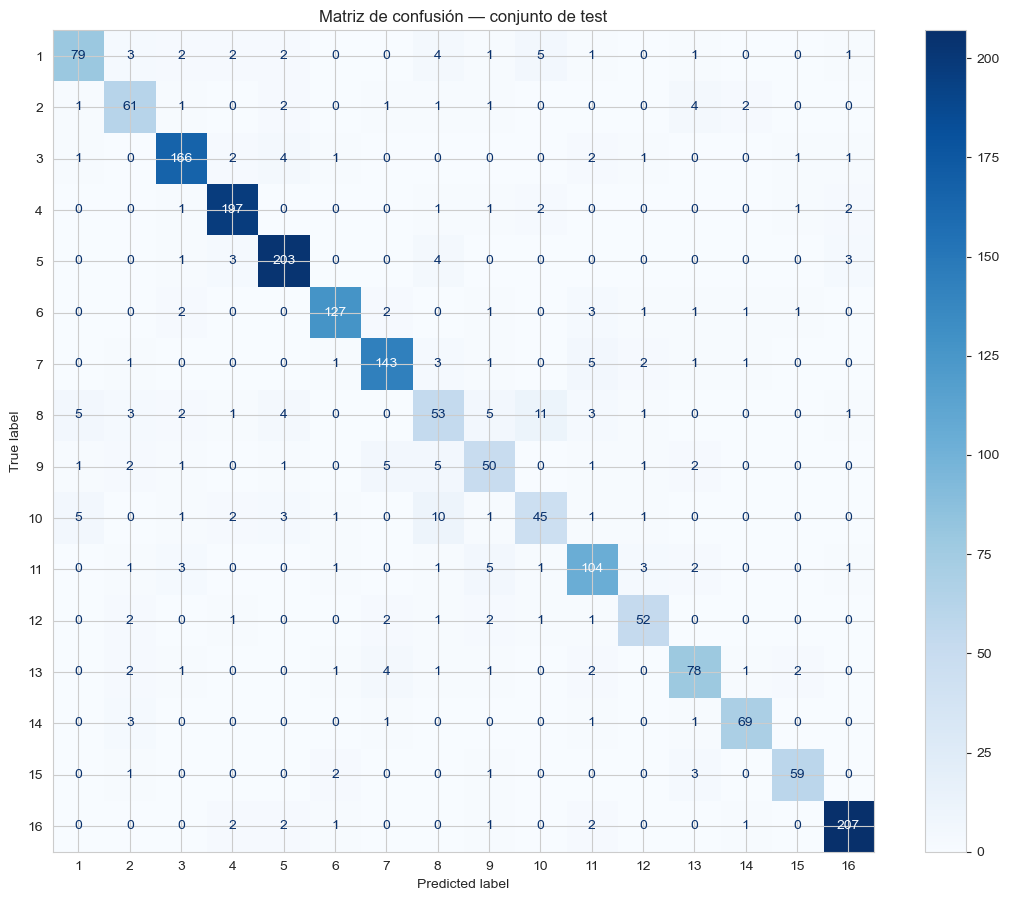

In [21]:
fig, ax = plt.subplots(figsize=(11, 9))
cm = confusion_matrix(y_test, y_pred, labels=sorted(y_test.unique()))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(y_test.unique()))
disp.plot(ax=ax, cmap='Blues', colorbar=True, values_format='d')
ax.set_title('Matriz de confusión — conjunto de test')
plt.tight_layout()
plt.show()


**Análisis de resultados:** el modelo alcanza una *accuracy* y un F1-macro superiores a 0.84 en el conjunto de
test, un desempeño sólido para un problema de 16 clases con desbalance. Las clases con mejor desempeño
(F1 > 0.9) corresponden a ODS con vocabulario muy distintivo y bien representado en los tópicos LSA de la
Sección 5 (**ODS 4 - Educación, ODS 5 - Género, ODS 16 - Paz y justicia**). Las clases con menor F1 (**ODS 8 -
Trabajo decente, ODS 9 - Industria e innovación, ODS 10 - Desigualdades**) son también las que en el análisis de
tópicos aparecían mezcladas con otros ejes temáticos (pobreza, ingresos, empleo), lo que es coherente: comparten
vocabulario económico/social con varios otros ODS, dificultando su separación.

## 8. Evidencia de desempeño sobre textos individuales

Se muestran a continuación las predicciones del modelo para varios textos del conjunto de **test** (no usados
durante el entrenamiento), junto con la etiqueta real, la etiqueta predicha y la probabilidad estimada para la
clase predicha, tal como lo solicita el entregable.

In [22]:
def mostrar_prediccion(idx_test, X_raw, y_real, y_pred_arr, y_proba_arr, clases):
    texto = X_raw.iloc[idx_test]
    real = y_real.iloc[idx_test]
    pred = y_pred_arr[idx_test]
    proba_pred = y_proba_arr[idx_test][list(clases).index(pred)]
    correcto = '✅ Correcta' if real == pred else '❌ Incorrecta'

    print('=' * 100)
    print(f'TEXTO: {texto[:400]}{"..." if len(texto) > 400 else ""}')
    print(f'ODS real     : {real} — {ODS_NAMES[real]}')
    print(f'ODS predicho : {pred} — {ODS_NAMES[pred]}  (probabilidad: {proba_pred:.2%})')
    print(f'Resultado    : {correcto}')


clases_modelo = modelo_final.named_steps['clf'].classes_
X_test_reset = X_test_raw.reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)

# Se seleccionan 6 ejemplos del conjunto de test: algunos aleatorios y, a propósito,
# también se incluye algún caso donde el modelo se equivoca, para mostrar un análisis honesto.
np.random.seed(RANDOM_STATE)
idx_random = np.random.choice(len(X_test_reset), size=4, replace=False)
idx_errores = np.where(y_pred != y_test.values)[0]
idx_ejemplo_error = idx_errores[:2] if len(idx_errores) >= 2 else idx_errores

indices_a_mostrar = list(idx_random) + list(idx_ejemplo_error)

for idx in indices_a_mostrar:
    mostrar_prediccion(idx, X_test_reset, y_test_reset, y_pred, y_proba, clases_modelo)


TEXTO: Este modo sigue siendo defendido por los principales donantes, pero se está volviendo mucho más modulado y abierto a las partes interesadas recientemente reconocidas preocupadas por los impactos ecológicos, el desplazamiento de la población local, a menudo minorías en los respectivos países, y otros resultados sociales, culturales y económicos localizados indeseables. que, al cambiar quién se bene...
ODS real     : 6 — Agua limpia y saneamiento
ODS predicho : 6 — Agua limpia y saneamiento  (probabilidad: 36.66%)
Resultado    : ✅ Correcta
TEXTO: El gasto per cápita se proyecta de acuerdo con suposiciones específicas y luego se multiplica por la población específica del grupo en el año de proyección. Sin embargo, el costo promedio por individuo en los grupos de mayor edad debería disminuir con el tiempo por dos razones: se supone que las ganancias de longevidad se traducen en años adicionales de buena salud ("envejecimiento saludable"), y ...
ODS real     : 3 — Salud y bienestar
O

Los ejemplos aleatorios muestran predicciones correctas con probabilidades altas, mientras que los ejemplos de
error seleccionados intencionalmente permiten observar el comportamiento del modelo en casos límite: en general
corresponden a textos con vocabulario compartido entre dos ODS relacionados (p. ej. pobreza/desigualdad/trabajo),
donde incluso la probabilidad asignada a la clase predicha suele ser más moderada, reflejando la incertidumbre
real del modelo — una señal saludable de que las probabilidades calibradas son informativas.

## 9. Conclusiones

* Se construyó un **pipeline reproducible** de scikit-learn que integra limpieza de texto en español (stopwords +
  *stemming*), representación **TF-IDF** con n-gramas, reducción de dimensionalidad con **TruncatedSVD (LSA)** y
  un clasificador lineal calibrado, evitando fuga de información mediante partición train/test previa a cualquier
  ajuste.
* El análisis **LSA** permitió identificar, de forma **no supervisada**, varios tópicos claramente interpretables
  y alineados con ODS específicos (educación, salud, agua, clima, derechos humanos/justicia, género y trabajo,
  pesca/acuicultura), validando cualitativamente que la representación TF-IDF conserva señal semántica relevante
  para el dominio.
* El modelo de clasificación final (**TF-IDF + SVD(200) + LinearSVC calibrado**), seleccionado mediante búsqueda
  de hiperparámetros con validación cruzada estratificada y F1-macro como métrica objetivo, alcanza un desempeño
  robusto en el conjunto de **test** (accuracy y F1-macro > 0.84), con mejor desempeño en ODS con vocabulario muy
  distintivo y mayores confusiones en ODS que comparten vocabulario socioeconómico.
* Como trabajo futuro se podrían explorar representaciones semánticas más ricas (embeddings preentrenados en
  español, p. ej. FastText o modelos tipo *sentence-transformers*), técnicas de sobremuestreo para las clases
  minoritarias, o modelos de *ensemble*, para intentar mejorar aún más el desempeño en las clases más difíciles.
